In [11]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [15]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [16]:
train["Survived"].mean()

np.float64(0.3838383838383838)

In [17]:
train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [18]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [19]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

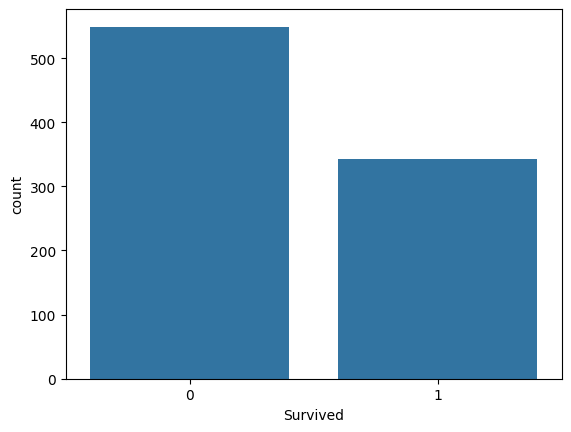

In [21]:
sns.countplot(x="Survived", data = train)
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

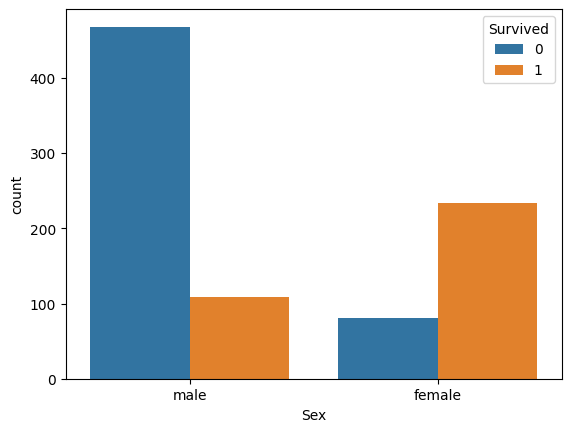

In [22]:
sns.countplot(x="Sex", hue ="Survived",data = train)

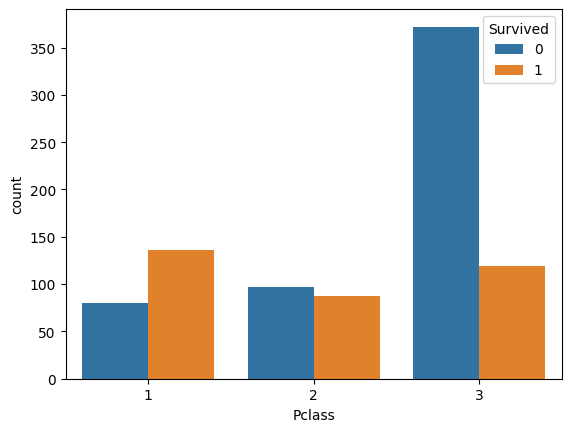

In [23]:
sns.countplot(x="Pclass", hue="Survived",data = train)
plt.show()

In [24]:
train["Deck"] = train["Cabin"].str[0]

In [25]:
train.groupby("Deck")["Survived"].mean()

Deck
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
T    0.000000
Name: Survived, dtype: float64

In [26]:
train["Title"] = train["Name"].str.extract (r" ([A-Za-z]+)\.")

In [27]:
train.groupby("Title")["Survived"].mean()

Title
Capt        0.000000
Col         0.500000
Countess    1.000000
Don         0.000000
Dr          0.428571
Jonkheer    0.000000
Lady        1.000000
Major       0.500000
Master      0.575000
Miss        0.697802
Mlle        1.000000
Mme         1.000000
Mr          0.156673
Mrs         0.792000
Ms          1.000000
Rev         0.000000
Sir         1.000000
Name: Survived, dtype: float64

In [28]:
train["Title"] = train["Title"].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
train["Title"] = train["Title"].replace('Mlle','Miss')
train["Title"] = train["Title"].replace('Ms','Miss')
train["Title"] = train["Title"].replace('Mme','Mrs')
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

In [29]:
train.groupby("Title")["Survived"].mean()

Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64

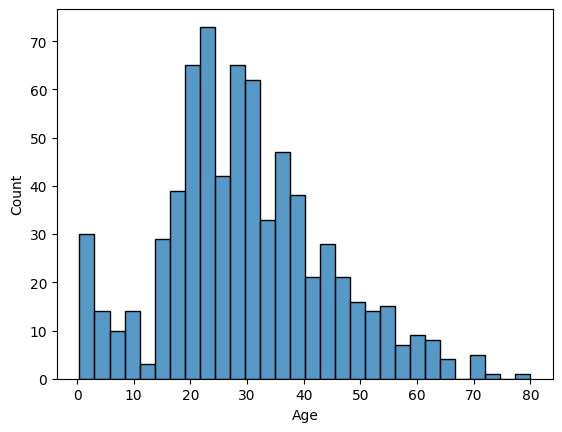

In [30]:
sns.histplot(train["Age"], bins=30)
plt.show()

In [31]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Deck           687
Title            0
FamilySize       0
dtype: int64

In [32]:
train["Age"] = train["Age"].fillna(train["Age"].median())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

In [33]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck           687
Title            0
FamilySize       0
dtype: int64

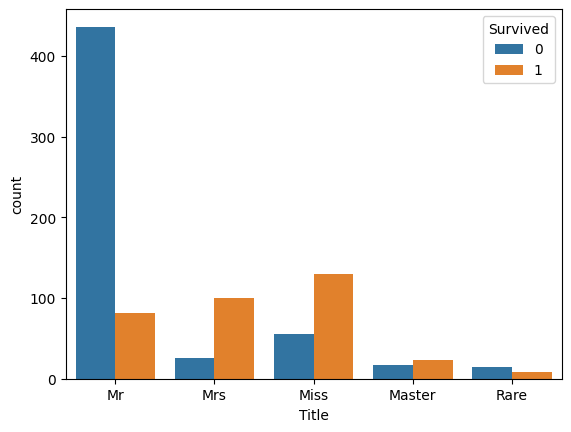

In [34]:
sns.countplot(x = "Title", hue= "Survived", data= train)
plt.show()

In [ ]:
# 모델 생성전 데이터 전처리 >> cabin 결측치 다수, name ticket passengerid 불필요
train = train.drop("Cabin", axis = 1)
train = train.drop(["Name", "Ticket","PassengerId"], axis = 1)

In [37]:
#문자 데이터를 숫자로 변환 >> ML모델은 숫자만 사용
train["Sex"] = train["Sex"].map({"male":0, "female":1})
train["Embarked"] = train["Embarked"].map({"S":0,"C":1,"Q":2})
title_map = {"Mr":0,"Miss":1,"Mrs":2,"Master":3,"Rare":4}
train["Title"] = train["Title"].map(title_map)

In [38]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,NaN,0,2
1,1,1,1,38.0,1,0,71.2833,1,C,2,2
2,1,3,1,26.0,0,0,7.9250,0,NaN,1,1
3,1,1,1,35.0,1,0,53.1000,0,C,2,2
4,0,3,0,35.0,0,0,8.0500,0,NaN,0,1


In [39]:
train = train.drop(["SibSp","Parch"], axis=1)

In [40]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,FamilySize
0,0,3,0,22.0,7.2500,0,NaN,0,2
1,1,1,1,38.0,71.2833,1,C,2,2
2,1,3,1,26.0,7.9250,0,NaN,1,1
3,1,1,1,35.0,53.1000,0,C,2,2
4,0,3,0,35.0,8.0500,0,NaN,0,1


In [41]:
train = train.drop(["Deck"],axis=1)

In [42]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,0,3,0,22.0,7.2500,0,0,2
1,1,1,1,38.0,71.2833,1,2,2
2,1,3,1,26.0,7.9250,0,1,1
3,1,1,1,35.0,53.1000,0,2,2
4,0,3,0,35.0,8.0500,0,0,1


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [44]:
X = train.drop("Survived",axis=1)
y = train["Survived"]

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [46]:
model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
model.score(X_test,y_test)

0.7988826815642458

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train,y_train)

rf.score(X_test,y_test)

0.8324022346368715

In [49]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)    

Fare          0.252551
Age           0.225410
Title         0.202873
Sex           0.122884
Pclass        0.091363
FamilySize    0.073221
Embarked      0.031698
dtype: float64

In [50]:
test = pd.read_csv("test.csv")

In [51]:
test_ids = test["PassengerId"]

test["Title"] = test["Name"].str.extract(r" ([A-Za-z]+)\.")
test["Title"] = test["Title"].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
test["Title"] = test["Title"].replace('Mlle','Miss')
test["Title"] = test["Title"].replace('Ms','Miss')
test["Title"] = test["Title"].replace('Mme','Mrs')

test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

test["Age"] = test["Age"].fillna(test["Age"].median())
test["Fare"] = test["Fare"].fillna(test["Fare"].median())
test["Embarked"] = test["Embarked"].fillna(test["Embarked"].mode()[0])

test["Sex"] = test["Sex"].map({"male":0, "female":1})
test["Embarked"] = test["Embarked"].map({"S":0, "C":1, "Q":2})
title_map = {"Mr":0, "Miss":1, "Mrs":2, "Master":3, "Rare":4}
test["Title"] = test["Title"].map(title_map)

test = test.drop(["Cabin","Name","Ticket","PassengerId","SibSp","Parch"], axis=1)

In [52]:
test.head()

,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,3,0,34.5,7.8292,2,0,1
1,3,1,47.0,7.0000,0,2,2
2,2,0,62.0,9.6875,2,0,1
3,3,0,27.0,8.6625,0,0,1
4,3,1,22.0,12.2875,0,2,3


In [53]:
pred = rf.predict(test)

In [57]:
sub_Tn = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": pred
})

In [58]:
sub_Tn.to_csv("sub_Tn.csv", index = False)

In [59]:
sub_Tn.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
